<a href="https://colab.research.google.com/github/Psyche-1/goit-ds-hw/blob/main/Hw2.3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [10]:
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

In [36]:
import numpy as np

Прочитайте csv файл (використовуйте функцію read_csv)

In [3]:
file_path = '/content/drive/MyDrive/Colab Notebooks/bestsellers with categories.csv'

df = pd.read_csv(file_path)
df

,Name,Author,User Rating,Reviews,Price,Year,Genre
0,10-Day Green Smoothie Cleanse,JJ Smith,4.7,17350,8,2016,Non Fiction
1,11/22/63: A Novel,Stephen King,4.6,2052,22,2011,Fiction
2,12 Rules for Life: An Antidote to Chaos,Jordan B. Peterson,4.7,18979,15,2018,Non Fiction
3,1984 (Signet Classics),George Orwell,4.7,21424,6,2017,Fiction
4,"5,000 Awesome Facts (About Everything!) (Natio...",National Geographic Kids,4.8,7665,12,2019,Non Fiction
...,...,...,...,...,...,...,...
545,Wrecking Ball (Diary of a Wimpy Kid Book 14),Jeff Kinney,4.9,9413,8,2019,Fiction
546,You Are a Badass: How to Stop Doubting Your Gr...,Jen Sincero,4.7,14331,8,2016,Non Fiction
547,You Are a Badass: How to Stop Doubting Your Gr...,Jen Sincero,4.7,14331,8,2017,Non Fiction
548,You Are a Badass: How to Stop Doubting Your Gr...,Jen Sincero,4.7,14331,8,2018,Non Fiction


Виведіть перші п'ять рядків (використовується функція head)

In [4]:
df.head()

,Name,Author,User Rating,Reviews,Price,Year,Genre
0,10-Day Green Smoothie Cleanse,JJ Smith,4.7,17350,8,2016,Non Fiction
1,11/22/63: A Novel,Stephen King,4.6,2052,22,2011,Fiction
2,12 Rules for Life: An Antidote to Chaos,Jordan B. Peterson,4.7,18979,15,2018,Non Fiction
3,1984 (Signet Classics),George Orwell,4.7,21424,6,2017,Fiction
4,"5,000 Awesome Facts (About Everything!) (Natio...",National Geographic Kids,4.8,7665,12,2019,Non Fiction


Виведіть розміри датасету (використовуйте атрибут shape)

In [5]:
df.shape

(550, 7)

In [6]:
df['Name'].nunique()

351

Про скільки книг зберігає дані датасет?
Відповідь: 550 книг, унікальних за назвою 351

In [7]:
df.columns = ['name', 'author', 'user_rating', 'reviews', 'price', 'year', 'genre']

Перевірте, чи у всіх рядків вистачає даних: виведіть кількість пропусків (na) у кожному зі стовпців (використовуйте функції isna та sum)

In [8]:
df.isna().sum()

,0
name,0
author,0
user_rating,0
reviews,0
price,0
year,0
genre,0


Чи є в якихось змінних пропуски? (Так / ні) Відповідь: ні

Перевірте, які є унікальні значення в колонці genre (використовуйте функцію unique)

In [9]:
df['genre'].unique()

array(['Non Fiction', 'Fiction'], dtype=object)

Які є унікальні жанри? Відповідь: 'Non Fiction', 'Fiction'

Тепер подивіться на розподіл цін: побудуйте діаграму (використовуйте kind='hist')

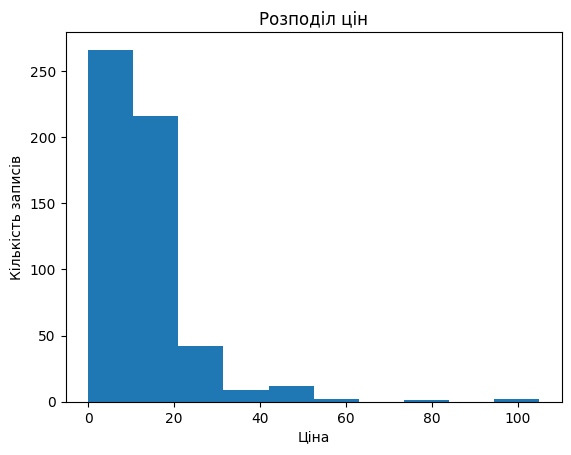

In [12]:
df['price'].plot(kind='hist')
plt.title('Розподіл цін')
plt.xlabel('Ціна')
plt.ylabel('Кількість записів')
plt.show()

Визначте, яка ціна у нас максимальна, мінімальна, середня, медіанна (використовуйте функції max, min, mean, median)

In [13]:
df['price'].max()

105

In [14]:
df['price'].min()

0

In [15]:
df['price'].mean()

np.float64(13.1)

In [16]:
df['price'].median()

11.0

Максимальна ціна? Відповідь: 105

Мінімальна ціна? Відповідь: 0

Середня ціна? Відповідь: 13.1

Медіанна ціна? Відповідь: 11

In [17]:
df['user_rating'].max()

4.9

Який рейтинг у датасеті найвищий? Відповідь: 4.9

In [18]:
(df['user_rating'] == df['user_rating'].max()).sum()

np.int64(52)

Скільки книг мають такий рейтинг? Відповідь: 52

In [19]:
max_reviews_index = df['reviews'].idxmax()
print(df.loc[max_reviews_index, 'name'])
print(df.loc[max_reviews_index, 'reviews'])

Where the Crawdads Sing
87841


Яка книга має найбільше відгуків? Відповідь: Where the Crawdads Sing, має 87841 відгуків

In [20]:
df_2015 = df[df['year'] == 2015]
max_price_index = df_2015['price'].idxmax()
df_2015.loc[max_price_index]

,277
name,Publication Manual of the American Psychologic...
author,American Psychological Association
user_rating,4.5
reviews,8580
price,46
year,2015
genre,Non Fiction


З тих книг, що потрапили до Топ-50 у 2015 році, яка книга найдорожча (можна використати проміжний датафрейм)? Відповідь: Publication Manual of the American Psychological Association, 6th Edition

In [21]:
df[(df['year'] == 2010) & (df['genre'] == 'Fiction')].shape[0]

20

Скільки книг жанру Fiction потрапили до Топ-50 у 2010 році (використовуйте &)? Відповідь: 20

In [22]:
df[(df['user_rating'] == 4.9) & (df['year'].isin([2010, 2011]))].shape[0]

1

Скільки книг з рейтингом 4.9 потрапило до рейтингу у 2010 та 2011 роках (використовуйте | або функцію isin)? Відповідь: 1

In [24]:
filtered_books = df[(df['year'] == 2015) & (df['price'] < 8)]
sorted_books = filtered_books.sort_values('price')
sorted_books.iloc[-1]

,253
name,Old School (Diary of a Wimpy Kid #10)
author,Jeff Kinney
user_rating,4.8
reviews,6169
price,7
year,2015
genre,Fiction


І насамкінець, давайте відсортуємо за зростанням ціни всі книги, які потрапили до рейтингу в 2015 році і коштують дешевше за 8 доларів (використовуйте функцію sort_values).
Яка книга остання у відсортованому списку? Відповідь: Old School (Diary of a Wimpy Kid #10)

In [25]:
df.groupby('genre')['price'].agg(['min', 'max'])

,min,max
genre,,
Fiction,0,82
Non Fiction,0,105


Для початку давайте подивимося на максимальну та мінімальну ціни для кожного з жанрів (використовуйте функції groupby та agg, для підрахунку мінімальних та максимальних значень використовуйте max та min). Не беріть усі стовпці, виберіть тільки потрібні вам

Максимальна ціна для жанру Fiction: Відповідь: 82

Мінімальна ціна для жанру Fiction: Відповідь: 0

Максимальна ціна для жанру Non Fiction: Відповідь: 105

Мінімальна ціна для жанру Non Fiction: Відповідь: 0

In [26]:
author_books_count = df.groupby('author')['name'].agg(['count'])
author_books_count.columns = ['books_count']
author_books_count.head()

,books_count
author,
Abraham Verghese,2
Adam Gasiewski,1
Adam Mansbach,1
Adir Levy,1
Admiral William H. McRaven,1


Тепер створіть новий датафрейм, який вміщатиме кількість книг для кожного з авторів (використовуйте функції groupby та agg, для підрахунку кількості використовуйте count). Не беріть усі стовпці, виберете тільки потрібні

In [27]:
author_books_count.shape

(248, 1)

In [29]:
author_books_count['books_count'].idxmax()

'Jeff Kinney'

In [28]:
author_books_count.max()

,0
books_count,12


Якої розмірності вийшла таблиця? Відповідь: (248 рядків, 1 стовпчик)

Який автор має найбільше книг? Відповідь: Jeff Kinney має 12 книг

Скільки книг цього автора? Відповідь: 12

In [30]:
author_avg_rating = df.groupby('author')['user_rating'].agg(['mean'])
author_avg_rating.columns = ['avg_rating']
author_avg_rating.head()

,avg_rating
author,
Abraham Verghese,4.6
Adam Gasiewski,4.4
Adam Mansbach,4.8
Adir Levy,4.8
Admiral William H. McRaven,4.7


In [32]:
author_avg_rating['avg_rating'].idxmin()

'Donna Tartt'

In [33]:
author_avg_rating['avg_rating'].min()

3.9

Тепер створіть другий датафрейм, який буде вміщати середній рейтинг для кожного автора (використовуйте функції groupby та agg, для підрахунку середнього значення використовуйте mean). Не беріть усі стовпці, виберете тільки потрібні

У якого автора середній рейтинг мінімальний? Відповідь: Donna Tartt

Який у цього автора середній рейтинг? Відповідь: 3.9

In [34]:
authors_stats = pd.concat([author_books_count, author_avg_rating], axis=1)
authors_stats

,books_count,avg_rating
author,,
Abraham Verghese,2,4.600000
Adam Gasiewski,1,4.400000
Adam Mansbach,1,4.800000
Adir Levy,1,4.800000
Admiral William H. McRaven,1,4.700000
...,...,...
Walter Isaacson,3,4.566667
William Davis,2,4.400000
William P. Young,2,4.600000


In [35]:
authors_stats_sorted = authors_stats.sort_values(by=['books_count', 'avg_rating'], ascending=True)
authors_stats_sorted

,books_count,avg_rating
author,,
Muriel Barbery,1,4.000000
Chris Cleave,1,4.100000
Ian K. Smith M.D.,1,4.100000
Pierre Dukan,1,4.100000
Elizabeth Strout,1,4.200000
...,...,...
American Psychological Association,10,4.500000
Suzanne Collins,11,4.663636
Gary Chapman,11,4.736364


З'єднайте останні два датафрейми так, щоб для кожного автора було видно кількість книг та середній рейтинг (Використовуйте функцію concat з параметром axis=1). Збережіть результат у змінну

Відсортуйте датафрейм за зростаючою кількістю книг та зростаючим рейтингом (використовуйте функцію sort_values)

Який автор перший у списку? Відповідь: Muriel Barbery

Додайте від 3 до 5 графіків функцій різного типу на ваш вибір. Задайте графікам оформлення, щоб кожен графік у своїй домашній роботі чимось відрізнявся і не був схожим на інші. Можна використовувати як matplotlib, так і seaborn.

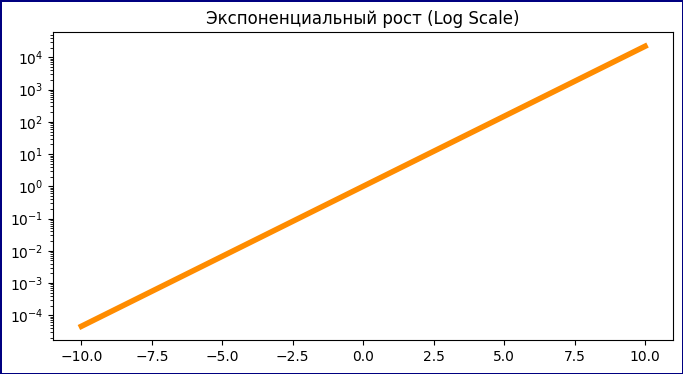

In [37]:
x = np.linspace(-10, 10, 200)

plt.figure(figsize=(8, 4), edgecolor='navy', linewidth=2)
plt.plot(x, np.exp(x), color="darkorange", lw=4)
plt.yscale('log')
plt.title("Экспоненційний ріст (Log Scale)")
plt.show()

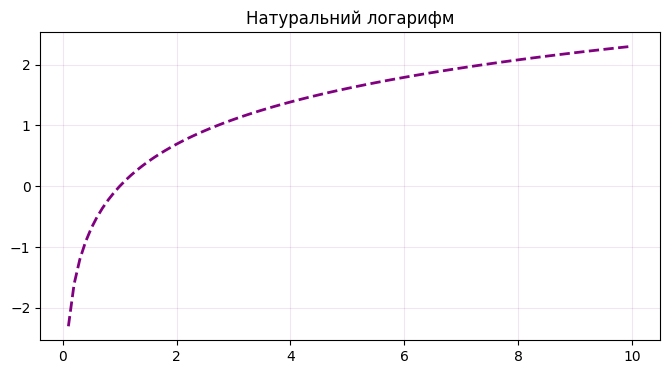

In [40]:
plt.figure(figsize=(8, 4))
x_log = np.linspace(0.1, 10, 100)
plt.plot(x_log, np.log(x_log), color="purple", ls='--', lw=2)
plt.grid(True, which='both', color='purple', alpha=0.1)
plt.title("Натуральний логарифм")
plt.show()

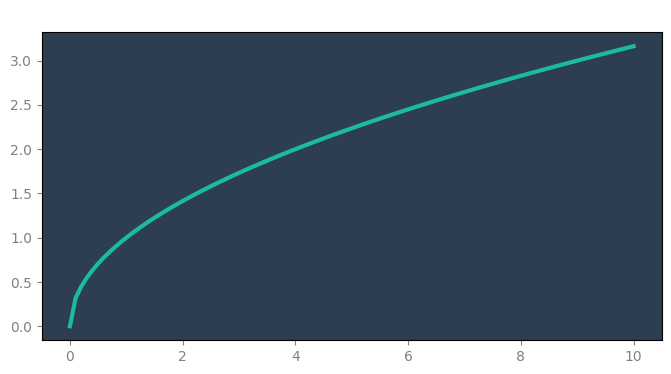

In [41]:
plt.figure(figsize=(8, 4))
plt.gca().set_facecolor('#2c3e50')
x_sqrt = np.linspace(0, 10, 100)
plt.plot(x_sqrt, np.sqrt(x_sqrt), color="#1abc9c", lw=3)
plt.title("Квадратний корінь", color='white')
plt.tick_params(colors='gray')
plt.show()